In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 768
Number of columns: 9


In [ ]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print("Diabetes Outcome Counts:")
print(df["Outcome"].value_counts())

Diabetes Outcome Counts:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
diabetic_count = df["Outcome"].sum()
total_patients = len(df)

proportion = diabetic_count / total_patients

print("Number of diabetic patients:", diabetic_count)
print("Total patients:", total_patients)
print("Sample proportion:", proportion)
print("Percentage of diabetic patients:", proportion * 100)

Number of diabetic patients: 268
Total patients: 768
Sample proportion: 0.3489583333333333
Percentage of diabetic patients: 34.89583333333333


In [ ]:
glucose_mean = df["Glucose"].mean()

print("Sample mean of Glucose:", glucose_mean)

Sample mean of Glucose: 120.89453125


In [ ]:
glucose_std = df["Glucose"].std()

print("Sample standard deviation of Glucose:", glucose_std)

Sample standard deviation of Glucose: 31.97261819513622


In [ ]:
mean = df["Glucose"].mean()
std = df["Glucose"].std()
n = len(df)

confidence_level = 0.95
alpha = 1 - confidence_level

standard_error = std / np.sqrt(n)

t_critical = stats.t.ppf(1 - alpha / 2, df=n-1)

margin_of_error = t_critical * standard_error

lower = mean - margin_of_error
upper = mean + margin_of_error

print("Sample mean:", mean)
print("Standard error:", standard_error)
print("Margin of error:", margin_of_error)
print("95% Confidence Interval:")
print("Lower bound:", lower)
print("Upper bound:", upper)

Sample mean: 120.89453125
Standard error: 1.153712482603689
Margin of error: 2.264808799054477
95% Confidence Interval:
Lower bound: 118.62972245094552
Upper bound: 123.15934004905448


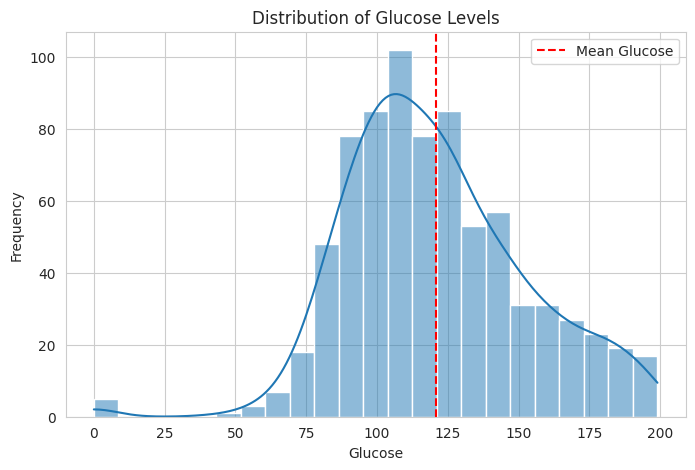

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Glucose"], kde=True)

plt.axvline(
    df["Glucose"].mean(),
    color="red",
    linestyle="--",
    label="Mean Glucose"
)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [ ]:
reference_value = 120

t_statistic, p_value = stats.ttest_1samp(
    df["Glucose"],
    reference_value
)

print("One-Sample t-Test")
print("------------------")
print("t-statistic:", t_statistic)
print("p-value:", p_value)

One-Sample t-Test
------------------
t-statistic: 0.7753502397592414
p-value: 0.4383717099127056


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis (H0).")
    print("Conclusion: There is significant evidence that the mean glucose level differs from 120.")
else:
    print("Decision: Fail to reject the null hypothesis (H0).")
    print("Conclusion: There is not enough evidence to conclude that the mean glucose level differs from 120.")

Decision: Fail to reject the null hypothesis (H0).
Conclusion: There is not enough evidence to conclude that the mean glucose level differs from 120.


In [ ]:
non_diabetic = df[df["Outcome"] == 0]
diabetic = df[df["Outcome"] == 1]

print("Non-diabetic patients:", len(non_diabetic))
print("Diabetic patients:", len(diabetic))

Non-diabetic patients: 500
Diabetic patients: 268


In [ ]:
mean_bmi_non_diabetic = non_diabetic["BMI"].mean()
mean_bmi_diabetic = diabetic["BMI"].mean()

print("Mean BMI of non-diabetic patients:", mean_bmi_non_diabetic)
print("Mean BMI of diabetic patients:", mean_bmi_diabetic)

Mean BMI of non-diabetic patients: 30.3042
Mean BMI of diabetic patients: 35.14253731343284


In [ ]:
t_statistic_bmi, p_value_bmi = stats.ttest_ind(
    non_diabetic["BMI"],
    diabetic["BMI"],
    equal_var=False
)

print("Two-Sample t-Test")
print("------------------")
print("t-statistic:", t_statistic_bmi)
print("p-value:", p_value_bmi)

Two-Sample t-Test
------------------
t-statistic: -8.619316881357946
p-value: 6.566237624708332e-17


In [ ]:
alpha = 0.05

if p_value_bmi < alpha:
    print("Decision: Reject the null hypothesis (H0).")
    print("Conclusion: Mean BMI is significantly different between diabetic and non-diabetic patients.")
else:
    print("Decision: Fail to reject the null hypothesis (H0).")
    print("Conclusion: There is not enough evidence of a difference in mean BMI.")

Decision: Reject the null hypothesis (H0).
Conclusion: Mean BMI is significantly different between diabetic and non-diabetic patients.


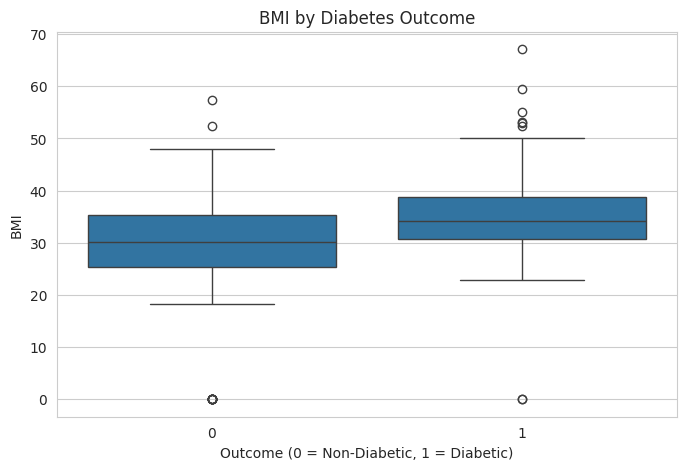

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("BMI")

plt.show()

In [ ]:
df["AgeGroup"] = np.where(
    df["Age"] < 40,
    "<40",
    ">=40"
)

print(df[["Age", "AgeGroup", "Outcome"]].head(10))

   Age AgeGroup  Outcome
0   50     >=40        1
1   31      <40        0
2   32      <40        1
3   21      <40        0
4   33      <40        1
5   30      <40        0
6   26      <40        1
7   29      <40        0
8   53     >=40        1
9   54     >=40        1


In [ ]:
contingency_table = pd.crosstab(
    df["AgeGroup"],
    df["Outcome"]
)

print("Contingency Table:")
print(contingency_table)

Contingency Table:
Outcome     0    1
AgeGroup          
<40       401  160
>=40       99  108


In [ ]:
chi2, p_value_chi, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-Square Test")
print("----------------")
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", p_value_chi)

Chi-Square Test
----------------
Chi-square statistic: 36.20335552648291
Degrees of freedom: 1
p-value: 1.7776420988318133e-09


In [ ]:
alpha = 0.05

if p_value_chi < alpha:
    print("Decision: Reject the null hypothesis (H0).")
    print("Conclusion: Age group and diabetes outcome are significantly associated.")
else:
    print("Decision: Fail to reject the null hypothesis (H0).")
    print("Conclusion: There is not enough evidence of an association between age group and diabetes outcome.")

Decision: Reject the null hypothesis (H0).
Conclusion: Age group and diabetes outcome are significantly associated.


In [ ]:
print("========== FINAL RESULTS ==========")

print("\n1. Point Estimate")
print("Mean Glucose =", round(df["Glucose"].mean(), 3))
print("Diabetes Proportion =", round(df["Outcome"].mean(), 3))

print("\n2. 95% Confidence Interval for Mean Glucose")
print("Lower =", round(lower, 3))
print("Upper =", round(upper, 3))

print("\n3. One-Sample t-Test")
print("t-statistic =", round(t_statistic, 3))
print("p-value =", round(p_value, 3))

print("\n4. Two-Sample t-Test for BMI")
print("t-statistic =", round(t_statistic_bmi, 3))
print("p-value =", p_value_bmi)

print("\n5. Chi-Square Test")
print("Chi-square =", round(chi2, 3))
print("Degrees of freedom =", degrees_of_freedom)
print("p-value =", p_value_chi)

========== FINAL RESULTS ==========

1. Point Estimate
Mean Glucose = 120.895
Diabetes Proportion = 0.349

2. 95% Confidence Interval for Mean Glucose
Lower = 118.63
Upper = 123.159

3. One-Sample t-Test
t-statistic = 0.775
p-value = 0.438

4. Two-Sample t-Test for BMI
t-statistic = -8.619
p-value = 6.566237624708332e-17

5. Chi-Square Test
Chi-square = 36.203
Degrees of freedom = 1
p-value = 1.7776420988318133e-09
